In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)

I0000 00:00:1788284498.243718    9698 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788284500.290020    9698 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788284506.552934    9698 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [5]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [6]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("Image height:", X_train.shape[1])
print("Image width:", X_train.shape[2])

print("Number of classes:", len(class_names))

print("Pixel minimum:", X_train.min())
print("Pixel maximum:", X_train.max())

Training samples: 60000
Testing samples: 10000
Image height: 28
Image width: 28
Number of classes: 10
Pixel minimum: 0
Pixel maximum: 255


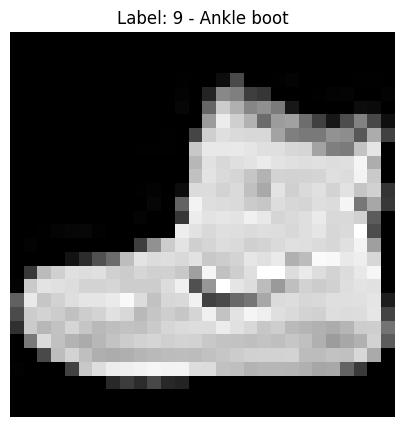

In [7]:
plt.figure(figsize=(5, 5))

plt.imshow(X_train[0], cmap="gray")

plt.title(
    f"Label: {y_train[0]} - {class_names[y_train[0]]}"
)

plt.axis("off")
plt.show()

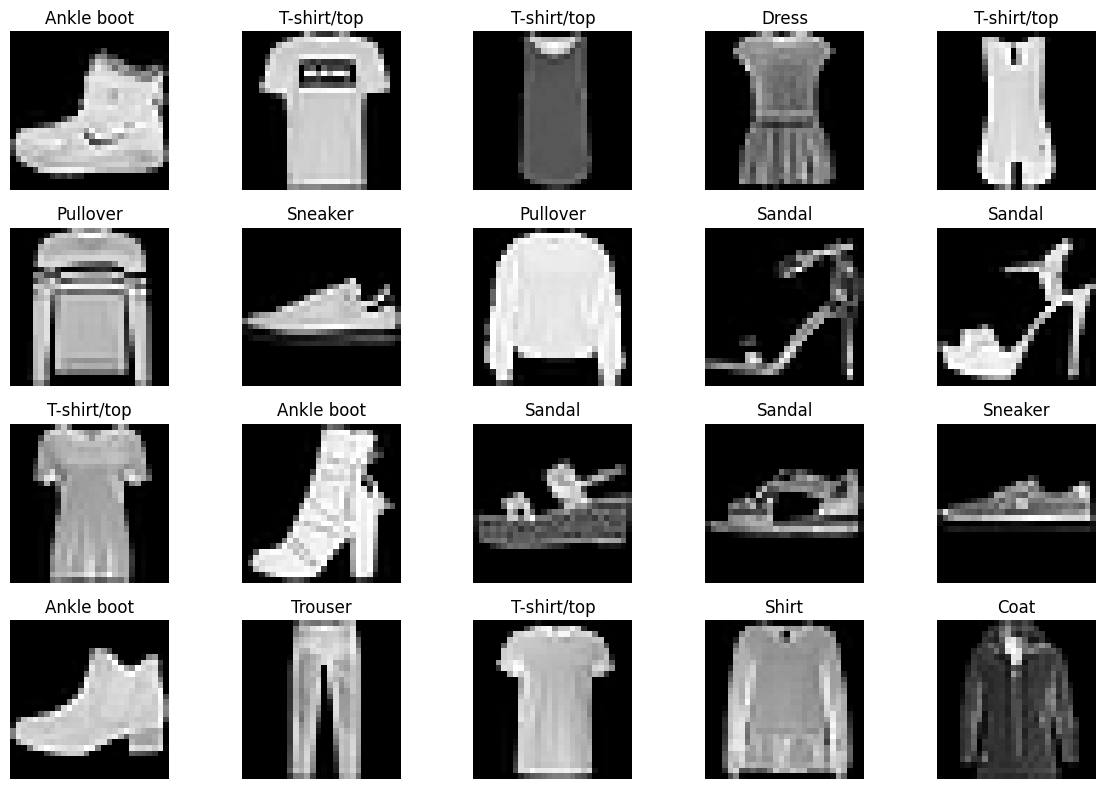

In [8]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(class_names[y_train[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
unique, counts = np.unique(y_train, return_counts=True)

class_distribution = pd.DataFrame({
    "Class": [class_names[i] for i in unique],
    "Count": counts
})

class_distribution

,Class,Count
0,T-shirt/top,6000
1,Trouser,6000
2,Pullover,6000
3,Dress,6000
4,Coat,6000
5,Sandal,6000
6,Shirt,6000
7,Sneaker,6000
8,Bag,6000
9,Ankle boot,6000


In [11]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training minimum:", X_train.min())
print("Training maximum:", X_train.max())

Training minimum: 0.0
Training maximum: 1.0


In [12]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


In [13]:
model = Sequential([
    
    Flatten(input_shape=(28, 28)),
    
    Dense(128, activation="relu"),
    
    Dropout(0.2),
    
    Dense(64, activation="relu"),
    
    Dropout(0.2),
    
    Dense(10, activation="softmax")
])

/home/anas/LEARNING/GEN-AI/python/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1788284640.863074    9698 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
from datetime import datetime

log_dir = os.path.join(
    "logs",
    "fit",
    datetime.now().strftime("%Y%m%d-%H%M%S")
)

print("Log directory:", log_dir)

Log directory: logs/fit/20260901-224436


In [17]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

In [18]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[
        early_stopping,
        tensorboard_callback
    ],
    verbose=1
)

Epoch 1/30


W0000 00:00:1788284700.708887    9698 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6892 - loss: 0.8740

W0000 00:00:1788284710.738985    9698 cpu_allocator_impl.cc:82] Allocation of 37632000 exceeds 10% of free system memory.


750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7692 - loss: 0.6454 - val_accuracy: 0.8463 - val_loss: 0.4293
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8371 - loss: 0.4477 - val_accuracy: 0.8610 - val_loss: 0.3839
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8528 - loss: 0.4059 - val_accuracy: 0.8608 - val_loss: 0.3722
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8593 - loss: 0.3819 - val_accuracy: 0.8685 - val_loss: 0.3575
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8669 - loss: 0.3643 - val_accuracy: 0.8692 - val_loss: 0.3542
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8714 - loss: 0.3494 - val_accuracy: 0.8729 - val_loss: 0.3480
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8750 - loss: 0.3385 - val_accuracy: 0.8718 - val_loss: 0.3466
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8798 - loss: 0.3264 - val_accuracy: 0.87

In [26]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8835 - loss: 0.3431
Test Loss: 0.34305161237716675
Test Accuracy: 0.8834999799728394


In [27]:
y_probability = model.predict(X_test)

print("Prediction shape:", y_probability.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Prediction shape: (10000, 10)


In [28]:
y_pred = np.argmax(y_probability, axis=1)

print("Predicted classes:")
print(y_pred[:20])

print("Actual classes:")
print(y_test[:20])

Predicted classes:
[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 2 8 0]
Actual classes:
[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0]


In [29]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.80      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.80      0.80      1000
       Dress       0.89      0.90      0.89      1000
        Coat       0.81      0.78      0.79      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.66      0.74      0.70      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



In [30]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[802   1  15  15   3   1 150   0  13   0]
 [  3 966   2  21   4   0   3   0   1   0]
 [ 12   1 796  11  88   0  90   0   2   0]
 [ 17   5   8 896  35   0  34   0   5   0]
 [  0   0  90  31 780   0  93   0   6   0]
 [  0   0   0   0   0 962   0  27   1  10]
 [ 96   1  71  27  52   0 740   0  13   0]
 [  0   0   0   0   0  13   0 966   0  21]
 [  5   1   1   2   2   2   6   4 977   0]
 [  0   0   0   0   0  11   1  38   0 950]]


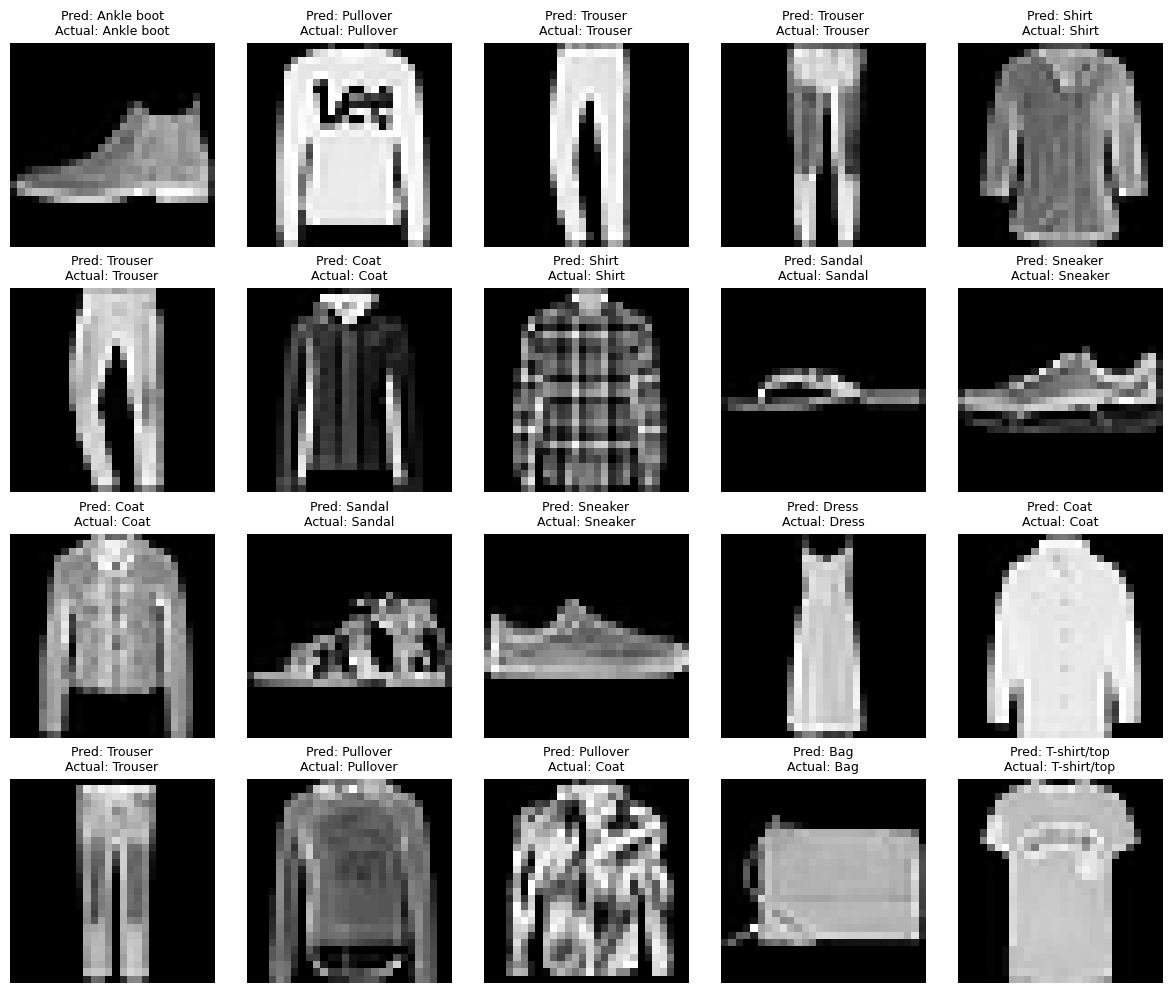

In [31]:
plt.figure(figsize=(12, 10))

for i in range(20):
    
    plt.subplot(4, 5, i + 1)
    
    plt.imshow(X_test[i], cmap="gray")
    
    predicted_class = class_names[y_pred[i]]
    actual_class = class_names[y_test[i]]
    
    plt.title(
        f"Pred: {predicted_class}\nActual: {actual_class}",
        fontsize=9
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
incorrect_indices = np.where(
    y_pred != y_test
)[0]

print("Incorrect predictions:", len(incorrect_indices))

Incorrect predictions: 1165


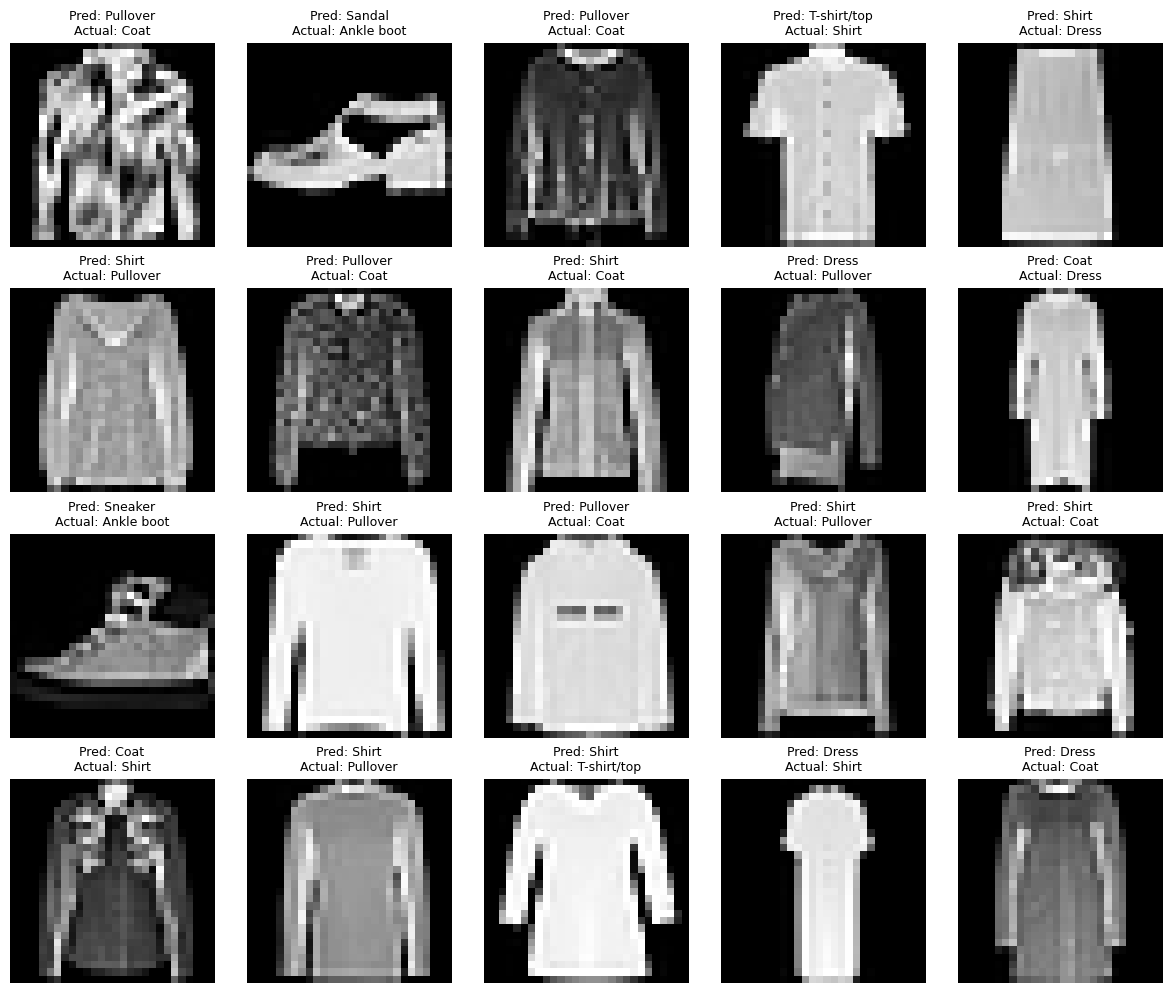

In [33]:
plt.figure(figsize=(12, 10))

for i in range(min(20, len(incorrect_indices))):
    
    index = incorrect_indices[i]
    
    plt.subplot(4, 5, i + 1)
    
    plt.imshow(X_test[index], cmap="gray")
    
    plt.title(
        f"Pred: {class_names[y_pred[index]]}\n"
        f"Actual: {class_names[y_test[index]]}",
        fontsize=9
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
model.save("model.keras")